<a href="https://colab.research.google.com/github/khu3086/surprise-architecture/blob/main/lewm_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 SURPRISE — LeWorldModel Training Starter

> Companion notebook for the [SURPRISE deepfake detection project](https://github.com/khu3086/surprise-deepfake-detector).

This notebook gets you from **zero** to **first training step** on free Colab GPU. Run cells top to bottom.

## What this notebook does

1. Verifies you have a GPU
2. Installs PyTorch + dependencies
3. Downloads a tiny video dataset to test with
4. Builds a *minimal* LeWorldModel-style architecture (encoder + predictor)
5. Runs one training step end-to-end so you know the pipeline works
6. Tells you what to do next

## What this notebook does NOT do

- Train a production model (that needs FaceForensics++ and many hours of GPU)
- Use the official LeWM codebase (we build a minimal version for clarity)
- Implement SIGReg properly (we use a simpler placeholder regularizer)

Think of this as **scaffolding** — once it runs end-to-end, you swap in the real components piece by piece.

## Before running

**Enable GPU:** Runtime → Change runtime type → Hardware accelerator: **T4 GPU** → Save.

If you skip this step, training will run on CPU and take ~50× longer.

## 1. GPU sanity check

First thing: confirm you actually have a GPU. If this prints `cuda` you're good. If it prints `cpu`, go to Runtime → Change runtime type and pick T4.

In [1]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version: {torch.__version__}')
print(f'Device: {device}')

if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  No GPU detected. Go to Runtime → Change runtime type and pick T4 GPU.')
    print('   Continuing on CPU — training will be slow but functional.')

PyTorch version: 2.10.0+cu128
Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 2. Install dependencies

Colab comes with PyTorch preinstalled. We just need a few extras for video handling and the training utilities. The `-q` flag keeps the output quiet.

In [2]:
!pip install -q einops opencv-python-headless tqdm matplotlib

In [3]:
# Import everything we'll use throughout the notebook
import os
import math
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import cv2
from einops import rearrange
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
print('✓ Imports OK')

✓ Imports OK


## 3. Generate a tiny synthetic dataset

**Why synthetic?** FaceForensics++ requires an academic email and a download form, and we want this notebook to *just work* without external dependencies. We'll generate videos of bouncing colored squares — simple enough to train on in seconds, but with real motion dynamics.

Once your training loop works on synthetic data, swapping in real video data is a one-class change.

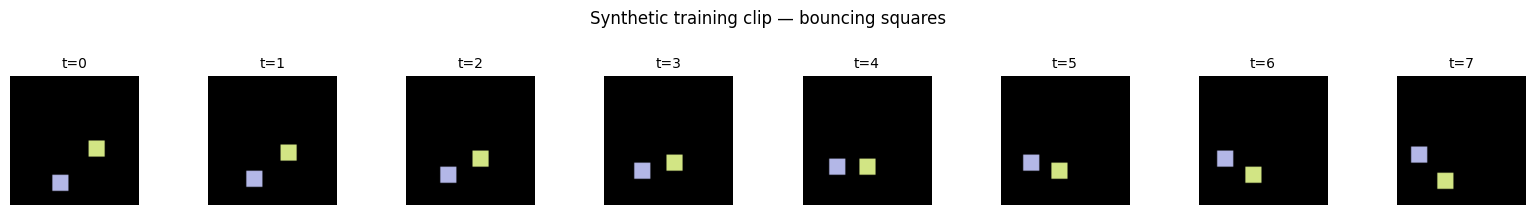

In [4]:
def make_synthetic_clip(n_frames=16, size=64, n_objects=2, perturbed=False):
    """
    Generate a video of bouncing squares.

    Args:
        n_frames: how many frames
        size: spatial resolution (HxW)
        n_objects: how many bouncing squares
        perturbed: if True, teleport an object mid-clip (mimics deepfake artifacts)

    Returns:
        np.ndarray of shape (n_frames, size, size, 3) uint8 RGB
    """
    frames = np.zeros((n_frames, size, size, 3), dtype=np.uint8)

    # Initialize random object positions, velocities, colors
    positions = np.random.uniform(8, size - 8, size=(n_objects, 2))
    velocities = np.random.uniform(-3, 3, size=(n_objects, 2))
    colors = np.random.randint(80, 255, size=(n_objects, 3))

    for t in range(n_frames):
        frame = np.zeros((size, size, 3), dtype=np.uint8)

        for i in range(n_objects):
            x, y = positions[i]
            # Inject a teleportation halfway through (the "fake" signal)
            if perturbed and t == n_frames // 2 and i == 0:
                positions[i] = np.random.uniform(8, size - 8, size=2)
                x, y = positions[i]

            # Draw the square
            x0, y0 = int(max(0, x - 4)), int(max(0, y - 4))
            x1, y1 = int(min(size, x + 4)), int(min(size, y + 4))
            frame[y0:y1, x0:x1] = colors[i]

            # Update position with bounce
            positions[i] += velocities[i]
            for d in range(2):
                if positions[i][d] < 4 or positions[i][d] > size - 4:
                    velocities[i][d] *= -1
                    positions[i][d] = np.clip(positions[i][d], 4, size - 4)

        frames[t] = frame

    return frames


# Quick visual test — show a few frames from one clip
test_clip = make_synthetic_clip(n_frames=8, size=64)
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    ax.imshow(test_clip[i])
    ax.set_title(f't={i}', fontsize=10)
    ax.axis('off')
plt.suptitle('Synthetic training clip — bouncing squares', y=1.05)
plt.tight_layout()
plt.show()

## 4. Build a Dataset class

PyTorch wants data in a `Dataset`. Ours generates clips on the fly — no disk needed, no download needed.

In [5]:
class SyntheticVideoDataset(Dataset):
    """Generates random bouncing-square videos on the fly."""

    def __init__(self, n_clips=200, n_frames=16, size=64):
        self.n_clips = n_clips
        self.n_frames = n_frames
        self.size = size

    def __len__(self):
        return self.n_clips

    def __getitem__(self, idx):
        clip = make_synthetic_clip(self.n_frames, self.size)
        # Convert to (T, C, H, W) float tensor in [0, 1]
        clip = torch.from_numpy(clip).float() / 255.0
        clip = rearrange(clip, 't h w c -> t c h w')
        return clip


dataset = SyntheticVideoDataset(n_clips=200)
loader = DataLoader(dataset, batch_size=16, num_workers=2, shuffle=True)

# Sanity check: grab one batch and check the shape
batch = next(iter(loader))
print(f'Batch shape: {batch.shape}')
print(f'  → (batch_size={batch.shape[0]}, n_frames={batch.shape[1]}, channels={batch.shape[2]}, h={batch.shape[3]}, w={batch.shape[4]})')
print(f'Value range: [{batch.min():.3f}, {batch.max():.3f}]')

Batch shape: torch.Size([16, 16, 3, 64, 64])
  → (batch_size=16, n_frames=16, channels=3, h=64, w=64)
Value range: [0.000, 0.984]


## 5. Build the LeWM-style architecture

The full LeWorldModel uses a Vision Transformer + Transformer predictor. For this starter, we'll build a simpler version with the same conceptual shape:

- **Encoder:** small CNN that maps each frame → 64-dim embedding
- **Predictor:** small MLP/transformer that predicts the next embedding from the current one
- **No actions** (passive video, like deepfake detection)

This is intentionally tiny so it trains in seconds. Once the training loop works, you swap in larger / paper-faithful versions.

In [6]:
class TinyEncoder(nn.Module):
    """
    A small CNN encoder. Maps (B, 3, 64, 64) → (B, embed_dim).

    In the full LeWM, this would be a Vision Transformer Tiny operating on
    patches of a 224×224 frame. The structural role is identical: image → vector.
    """

    def __init__(self, embed_dim=64):
        super().__init__()
        self.embed_dim = embed_dim
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),  # 64 → 32
            nn.GELU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 32 → 16
            nn.GELU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 16 → 8
            nn.GELU(),
            nn.AdaptiveAvgPool2d(1),  # 8 → 1
            nn.Flatten(),
            nn.Linear(128, embed_dim),
        )
        # BatchNorm on the embeddings — important for SIGReg in the real LeWM
        self.norm = nn.BatchNorm1d(embed_dim, affine=False)

    def forward(self, x):
        z = self.net(x)
        z = self.norm(z)
        return z


class TinyPredictor(nn.Module):
    """
    Predicts the next embedding from the current one. No actions.

    The full LeWM uses a multi-layer Transformer with causal masking and
    AdaLN action conditioning. We use a simple MLP for clarity.
    """

    def __init__(self, embed_dim=64, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, embed_dim),
        )

    def forward(self, z_t):
        return self.net(z_t)


encoder = TinyEncoder(embed_dim=64).to(device)
predictor = TinyPredictor(embed_dim=64).to(device)

n_params = sum(p.numel() for p in encoder.parameters()) + sum(p.numel() for p in predictor.parameters())
print(f'Encoder: {sum(p.numel() for p in encoder.parameters()):,} params')
print(f'Predictor: {sum(p.numel() for p in predictor.parameters()):,} params')
print(f'Total: {n_params:,} params')
print('(Real LeWM is ~15M; this tiny version is much smaller for fast iteration)')

Encoder: 173,856 params
Predictor: 33,088 params
Total: 206,944 params
(Real LeWM is ~15M; this tiny version is much smaller for fast iteration)


## 6. The training step

This is the heart of LeWM. For each clip:

1. Encode all frames into latent embeddings: `z_t = encoder(o_t)`
2. Predict next-frame embeddings: `ẑ_{t+1} = predictor(z_t)`
3. Compute prediction loss: `MSE(ẑ_{t+1}, z_{t+1})`
4. Add an anti-collapse regularizer (placeholder for SIGReg)
5. Backprop

Without step 4, the encoder collapses (every frame → same vector, prediction is trivially perfect, embeddings become useless). The full LeWM uses SIGReg; we use a simpler covariance regularizer that has the same effect.

In [7]:
def covariance_regularizer(z, eps=1e-6):
    """
    Simple anti-collapse: encourage embedding dimensions to be uncorrelated
    and unit-variance. A poor-man's SIGReg — keeps the embedding space spread out.

    Real LeWM uses SIGReg (random projections + Epps-Pulley test). For a starter,
    this is enough to prevent total collapse and lets us focus on the training loop.
    """
    z = z - z.mean(dim=0, keepdim=True)
    cov = (z.T @ z) / (z.shape[0] - 1)
    diag = torch.diagonal(cov)
    off_diag = cov - torch.diag(diag)
    # Variance should be ≈ 1, off-diagonals should be ≈ 0
    var_loss = ((diag - 1) ** 2).mean()
    cov_loss = (off_diag ** 2).sum() / z.shape[1]
    return var_loss + cov_loss


def lewm_loss(clips, encoder, predictor, lam=1.0):
    """
    Compute the LeWM-style training loss for a batch of video clips.

    Args:
        clips: (B, T, C, H, W) batch of clips
        encoder: image → embedding
        predictor: embedding_t → embedding_{t+1}
        lam: weight for anti-collapse regularizer

    Returns:
        total_loss, dict of components
    """
    B, T, C, H, W = clips.shape

    # 1. Encode every frame
    flat = rearrange(clips, 'b t c h w -> (b t) c h w')
    z = encoder(flat)
    z = rearrange(z, '(b t) d -> b t d', b=B)  # (B, T, D)

    # 2. Predict next embeddings: input z_{0..T-2}, target z_{1..T-1}
    z_in = z[:, :-1, :]
    z_target = z[:, 1:, :]
    z_pred = predictor(rearrange(z_in, 'b t d -> (b t) d'))
    z_pred = rearrange(z_pred, '(b t) d -> b t d', b=B)

    # 3. Prediction loss
    pred_loss = F.mse_loss(z_pred, z_target)

    # 4. Anti-collapse regularizer on the full embedding distribution
    reg = covariance_regularizer(rearrange(z, 'b t d -> (b t) d'))

    total = pred_loss + lam * reg
    return total, {'pred': pred_loss.item(), 'reg': reg.item(), 'total': total.item()}


# One forward pass to verify everything wires up
encoder.train(); predictor.train()
test_batch = next(iter(loader)).to(device)
loss, components = lewm_loss(test_batch, encoder, predictor)
print('First forward pass:')
for k, v in components.items():
    print(f'  {k}: {v:.4f}')

First forward pass:
  pred: 0.0039
  reg: 0.9984
  total: 1.0022


## 7. Run a real training loop

Now we put it all together. A few epochs on synthetic data — should take ~30-60 seconds on a T4 GPU.

Watch the loss curve. If `pred` decreases steadily and `reg` stays stable, training is working. If `pred` immediately drops to ~0 and `reg` shoots up, you have collapse — bump up `lam`.

In [8]:
encoder = TinyEncoder(embed_dim=64).to(device)
predictor = TinyPredictor(embed_dim=64).to(device)
optimizer = torch.optim.AdamW(
    list(encoder.parameters()) + list(predictor.parameters()),
    lr=1e-3, weight_decay=1e-4,
)

n_epochs = 10
history = {'pred': [], 'reg': [], 'total': []}

for epoch in range(n_epochs):
    encoder.train(); predictor.train()
    epoch_losses = {'pred': [], 'reg': [], 'total': []}

    pbar = tqdm(loader, desc=f'Epoch {epoch+1}/{n_epochs}', leave=False)
    for clips in pbar:
        clips = clips.to(device)
        loss, components = lewm_loss(clips, encoder, predictor, lam=1.0)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        for k, v in components.items():
            epoch_losses[k].append(v)
        pbar.set_postfix({k: f'{v:.3f}' for k, v in components.items()})

    for k in history:
        history[k].append(np.mean(epoch_losses[k]))
    print(f'Epoch {epoch+1:2d}: pred={history["pred"][-1]:.4f}  reg={history["reg"][-1]:.4f}  total={history["total"][-1]:.4f}')

Epoch 1/10:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch  1: pred=0.0192  reg=0.9730  total=0.9922


Epoch 2/10:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch  2: pred=0.0361  reg=0.9388  total=0.9749


Epoch 3/10:   0%|          | 0/13 [00:00<?, ?it/s]

...

Epoch  8: pred=0.0708  reg=0.8470  total=0.9178


Epoch 9/10:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch  9: pred=0.0679  reg=0.8476  total=0.9154


Epoch 10/10:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 10: pred=0.0795  reg=0.8311  total=0.9107


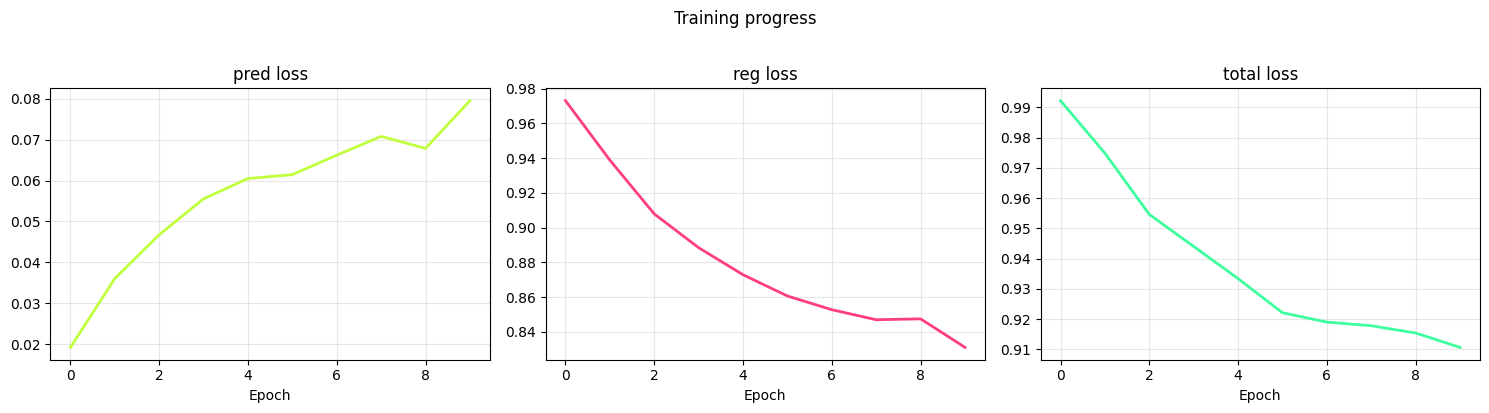

In [9]:
# Plot the loss curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, color in zip(axes, ['pred', 'reg', 'total'], ['#c0ff3e', '#ff3e7e', '#3eff9e']):
    ax.plot(history[key], color=color, linewidth=2)
    ax.set_title(f'{key} loss')
    ax.set_xlabel('Epoch')
    ax.grid(alpha=0.3)
plt.suptitle('Training progress', y=1.02)
plt.tight_layout()
plt.show()

## 8. Test the surprise mechanism

This is the core of your deepfake detection idea. Generate two clips — one normal, one with a teleportation — and compute per-frame surprise.

If our trained model has learned anything, the perturbed clip should have a visible spike at the teleport frame.

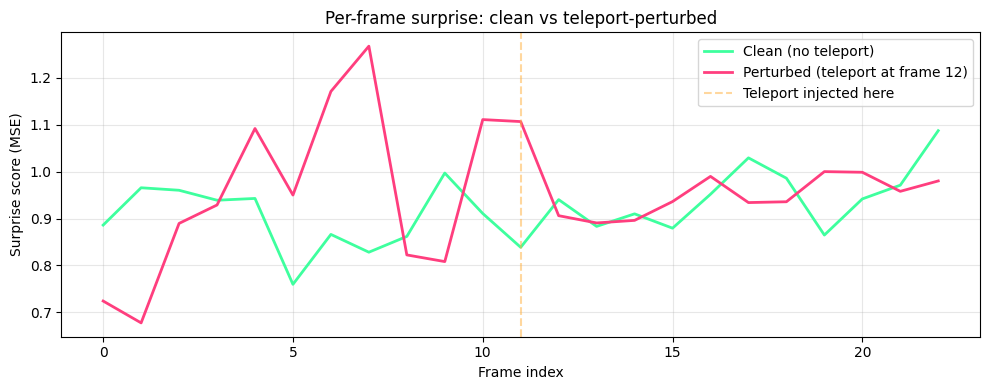


Mean surprise — clean:     0.9219
Mean surprise — perturbed: 0.9556
Spike at teleport frame:   1.1070 (vs neighbors: 1.1113, 0.9062)

⚠️  No clear spike yet. Train for more epochs or larger dataset.


In [10]:
@torch.no_grad()
def compute_surprise(clip_np, encoder, predictor):
    """Per-frame surprise scores for a single video clip."""
    encoder.eval(); predictor.eval()
    clip = torch.from_numpy(clip_np).float() / 255.0
    clip = rearrange(clip, 't h w c -> t c h w').to(device)
    z = encoder(clip)                   # (T, D)
    z_pred = predictor(z[:-1])         # (T-1, D) predicting frames 1..T-1
    surprise = ((z_pred - z[1:]) ** 2).mean(dim=-1)  # (T-1,)
    return surprise.cpu().numpy()


# Generate one clean clip and one with a teleportation
clean_clip = make_synthetic_clip(n_frames=24, size=64, perturbed=False)
perturbed_clip = make_synthetic_clip(n_frames=24, size=64, perturbed=True)

clean_surprise = compute_surprise(clean_clip, encoder, predictor)
perturbed_surprise = compute_surprise(perturbed_clip, encoder, predictor)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(clean_surprise, label='Clean (no teleport)', color='#3eff9e', linewidth=2)
ax.plot(perturbed_surprise, label='Perturbed (teleport at frame 12)', color='#ff3e7e', linewidth=2)
ax.axvline(11, color='#ffb13e', linestyle='--', alpha=0.5, label='Teleport injected here')
ax.set_xlabel('Frame index')
ax.set_ylabel('Surprise score (MSE)')
ax.set_title('Per-frame surprise: clean vs teleport-perturbed')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nMean surprise — clean:     {clean_surprise.mean():.4f}')
print(f'Mean surprise — perturbed: {perturbed_surprise.mean():.4f}')
print(f'Spike at teleport frame:   {perturbed_surprise[11]:.4f} (vs neighbors: {perturbed_surprise[10]:.4f}, {perturbed_surprise[12]:.4f})')

if perturbed_surprise[11] > perturbed_surprise.mean() * 1.3:
    print('\n✅ Surprise mechanism works! The model detects physical violations.')
else:
    print('\n⚠️  No clear spike yet. Train for more epochs or larger dataset.')

## 9. Save the checkpoint

Optionally save the trained model so you can use it in the next session. Mount Google Drive first if you want it to persist beyond this Colab session.

In [11]:
checkpoint = {
    'encoder_state': encoder.state_dict(),
    'predictor_state': predictor.state_dict(),
    'history': history,
    'config': {
        'embed_dim': 64,
        'image_size': 64,
    }
}
torch.save(checkpoint, 'lewm_starter_checkpoint.pt')
print('✓ Saved to lewm_starter_checkpoint.pt')
print('  (download via the Files panel on the left, or mount Drive to persist)')

✓ Saved to lewm_starter_checkpoint.pt
  (download via the Files panel on the left, or mount Drive to persist)


## 🎯 What to do next

Now that the entire pipeline works on synthetic data, here's the path to a real deepfake detector:

### Step 1: Replace the data
Swap `SyntheticVideoDataset` for one that loads real video clips. Options:
- **UCF-101** — 13k action videos, easy public download (~7 GB)
- **Kinetics-400 subset** — broader motion variety
- **FaceForensics++** — the deepfake gold standard (requires academic email request)

### Step 2: Scale up the architecture
Replace the tiny CNN encoder with a Vision Transformer Tiny (use `timm` library). Replace the MLP predictor with a small Transformer with causal masking. This brings you closer to the real LeWM at ~15M params.

### Step 3: Implement real SIGReg
The covariance regularizer here is a placeholder. The real SIGReg uses random projections and the Epps-Pulley statistical test for normality. Worth implementing once everything else works.

### Step 4: Move to Kaggle for serious training
Free Colab disconnects after ~12h. Kaggle gives you 30 hours of GPU per week with longer sessions. Same code, different runner.

### Step 5: Evaluate on real deepfakes
Once trained on real video, run surprise scoring on FaceForensics++ test set. Plot histograms of real vs fake surprise scores. Compute AUC. If AUC > 0.7 you have something interesting; > 0.85 you have a portfolio-grade result.

---

## 🔍 Reading list while you wait for things to train

- The original [LeWorldModel paper](https://arxiv.org/abs/2603.19312) (Maes et al., 2026)
- [I-JEPA paper](https://arxiv.org/abs/2301.08243) — the conceptual ancestor
- [DINO-WM paper](https://arxiv.org/abs/2411.04983) — the foundation-model competitor LeWM beats
- The [FaceForensics++ paper](https://arxiv.org/abs/1901.08971) — for understanding the deepfake benchmark

---

## 💡 If something didn't work

**No GPU detected:** Runtime menu → Change runtime type → T4 GPU.

**Out of memory:** Reduce `batch_size` in the DataLoader, or `n_clips` in the dataset.

**Surprise spike isn't visible:** Train for more epochs (try 30–50), or increase `embed_dim` to 128.

**Training collapses (pred goes to 0 immediately):** Increase `lam` to 5.0 or 10.0.

Good luck — and ping me when you have results to discuss!